# Phase 2 — The point-mass ("3-DOF") aircraft

The first aircraft model treats the F-16 as a **point mass** with forces acting on it. It
ignores how the aircraft rotates about its center of gravity, and instead lets the pilot (or
agent) command the **angle of attack** and the **roll rate** directly, with a realistic lag.

Why start with this?

* it is **fast** (a few µs per step), ideal to prototype RL tasks and rewards;
* it already captures what matters for maneuvering: energy, turn rate, climb, speed limits;
* it is easy to validate against published F-16 performance.

Code: `src/jetfighter/aircraft/` — `dynamics_3dof.py`, `aero_polar.py`, `propulsion.py`,
`performance.py`; parameters in `configs/aircraft/f16.yaml`.

In [1]:
%matplotlib inline
import math
import time

import matplotlib.pyplot as plt
import numpy as np

from jetfighter.aircraft import dynamics_3dof as d3
from jetfighter.aircraft import performance as perf
from jetfighter.aircraft.params import load_aircraft
from jetfighter.core.atmosphere import isa_scalar
from jetfighter.core.integrators import simulate
from jetfighter.viz.style import GRID, INK, INK_2, SERIES, apply_style

apply_style()
plt.rcParams["figure.dpi"] = 110
DEG = math.pi / 180

params = load_aircraft("f16")
ac = d3.PointMassAircraft(params)
print(
    f"F-16 model: mass {params.mass.mass:.0f} kg, wing area {params.geometry.wing_area} m², "
    f"span {params.geometry.wing_span} m (aspect ratio {params.geometry.aspect_ratio:.1f})"
)
print(
    f"thrust at sea level: {params.propulsion.thrust_mil_sl / 1e3:.0f} kN dry, "
    f"{params.propulsion.thrust_max_sl / 1e3:.0f} kN with afterburner"
)

F-16 model: mass 9295 kg, wing area 27.87 m², span 9.144 m (aspect ratio 3.0)
thrust at sea level: 56 kN dry, 89 kN with afterburner


Every parameter lives in a YAML file with its source (`[SL]` Stevens & Lewis, `[PUB]` public
figures, `[EST]` project estimate). Changing aircraft means changing a file, not the code.

## 1. Equations of motion

Four forces act on the aircraft: **thrust** $T$ along the fuselage, **lift** $L$ perpendicular to
the velocity, **drag** $D$ opposite to it, and **weight** $mg$. Writing Newton's law along the
flight path gives the textbook equations, with $V$ the airspeed, $\gamma$ the flight-path
angle (climb angle), $\chi$ the course, $\mu$ the bank angle around the velocity vector:

$$\dot V = \frac{T\cos\alpha - D}{m} - g\sin\gamma$$
$$\dot\gamma = \frac{(L + T\sin\alpha)\cos\mu - mg\cos\gamma}{mV}$$
$$\dot\chi = \frac{(L + T\sin\alpha)\sin\mu}{mV\cos\gamma}$$

**Problem:** the last equation divides by $\cos\gamma$ — it is singular in vertical flight, i.e.
in the middle of a loop. Same issue as Euler angles in notebook 1, same fix: the model
integrates the orientation of the **wind frame** as a quaternion $q_w$. With $a = [a_x, a_y, a_z]$
the acceleration in wind axes and $p_w$ the commanded roll rate around the velocity:

$$\dot V = a_x, \qquad \omega_w = \left[p_w,\ -\frac{a_z}{V},\ \frac{a_y}{V}\right], \qquad
  \dot q_w = \tfrac12\, q_w \otimes [0, \omega_w]$$

This is strictly equivalent to the equations above away from the vertical, and remains valid
through it. The state has 11 variables:
`[north, east, h, V, q0..q3, α, p_w, engine power]`, and 3 controls:
`[throttle, α command, roll-rate command]`.

The controls do not act instantly: $\alpha$ follows its command with a first-order lag
($\tau = 0.25$ s, rate-limited), the roll rate with $\tau = 0.2$ s, the engine with
$\tau = 1$ s — plus an **α limiter** (≤ 25°) and a **load-factor limiter** (−3 g … +9 g), like a
real fly-by-wire system.

## 2. Aerodynamics: a Mach-dependent drag polar

$$C_L = C_{L0} + C_{L\alpha}\, s(M)\,\alpha, \qquad C_D = C_{D0}(M) + k(M)\, C_L^2, \qquad
  L = \bar q S C_L, \quad D = \bar q S C_D$$

$C_{D0}$ is the drag at zero lift (skin friction and form drag), $kC_L^2$ is the **induced
drag** — the price of producing lift. Both rise sharply near Mach 1 (the transonic drag rise).

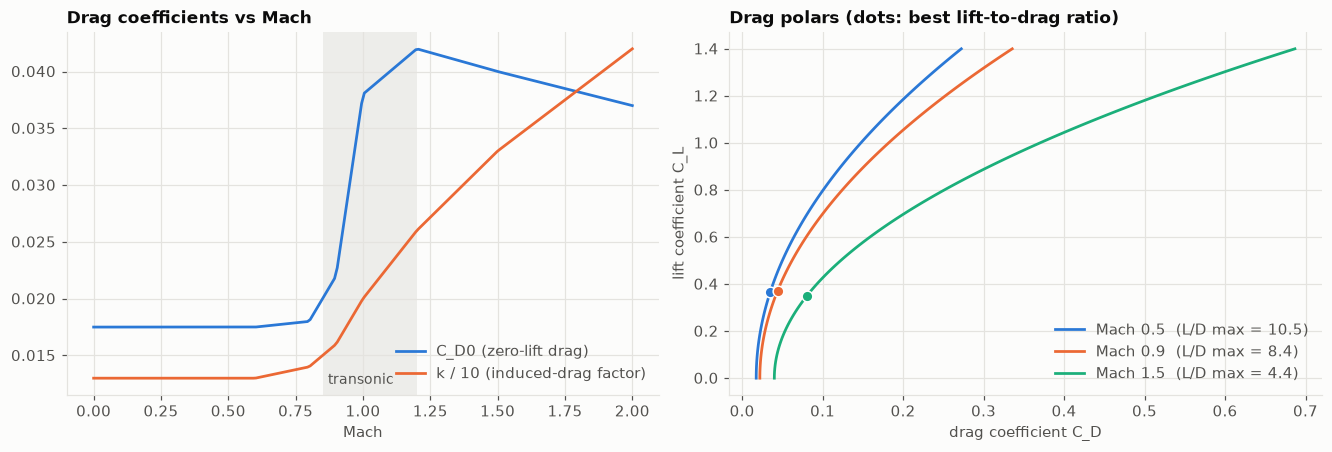

In [2]:
aero = ac.aero
machs = np.linspace(0, 2, 200)
fig, axes = plt.subplots(1, 2, figsize=(12, 4), layout="constrained")
axes[0].plot(machs, [aero.cd0(m) for m in machs], color=SERIES[0], label="C_D0 (zero-lift drag)")
axes[0].plot(
    machs,
    [aero.k_induced(m) / 10 for m in machs],
    color=SERIES[1],
    label="k / 10 (induced-drag factor)",
)
axes[0].axvspan(0.85, 1.2, color=GRID, alpha=0.6, linewidth=0)
axes[0].text(0.87, 0.0125, "transonic", color=INK_2, fontsize=9)
axes[0].set_xlabel("Mach"), axes[0].set_title("Drag coefficients vs Mach")
axes[0].legend(loc="lower right")

cl = np.linspace(0, 1.4, 100)
for m, color in zip((0.5, 0.9, 1.5), SERIES, strict=True):
    ld = aero.max_lift_to_drag(m)
    axes[1].plot(
        [aero.cd(c, m) for c in cl], cl, color=color, label=f"Mach {m}  (L/D max = {ld:.1f})"
    )
    cl_opt = math.sqrt(aero.cd0(m) / aero.k_induced(m))
    axes[1].plot(
        aero.cd(cl_opt, m), cl_opt, "o", color=color, markersize=7, markeredgecolor="white"
    )
axes[1].set_xlabel("drag coefficient C_D"), axes[1].set_ylabel("lift coefficient C_L")
axes[1].set_title("Drag polars (dots: best lift-to-drag ratio)")
axes[1].legend(loc="lower right")
plt.show()

The best glide ratio occurs where induced drag equals zero-lift drag,
$C_L^* = \sqrt{C_{D0}/k}$, giving $(L/D)_{max} = 1/(2\sqrt{C_{D0}\,k})$ ≈ 10 in subsonic flight —
typical of a fighter, whose short wings trade efficiency for agility.

## 3. Propulsion

A parametric turbofan with afterburner. Thrust at sea level is interpolated between idle,
full dry ("MIL") and full afterburner ("MAX"), then corrected for altitude and ram effect:

$$T = T_{SL}(P)\,\cdot\,\min\!\left[\left(\frac{\rho}{\rho_0}\right)^{1.15}(1 + k_{ram} M),\ 1.3\right]$$

The exponent 1.15 reproduces the static thrust tables of the Stevens & Lewis F-16 model; the
1.3 cap stands for the engine's temperature and pressure limits at low altitude and high speed.

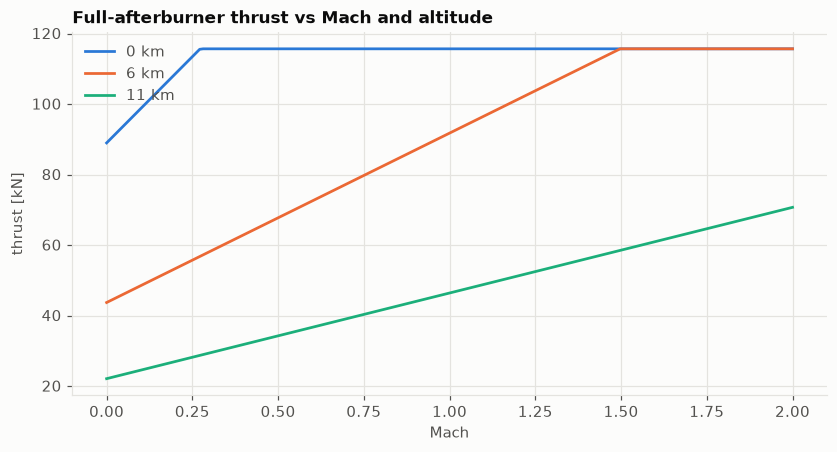

In [3]:
fig, ax = plt.subplots(figsize=(7.5, 4), layout="constrained")
for alt, color in zip((0, 6000, 11_000), SERIES, strict=True):
    rho, a = isa_scalar(alt)[2], isa_scalar(alt)[3]
    ax.plot(
        machs,
        [ac.engine.thrust(1.0, rho, m) / 1e3 for m in machs],
        color=color,
        label=f"{alt / 1000:.0f} km",
    )
ax.set_xlabel("Mach"), ax.set_ylabel("thrust [kN]")
ax.set_title("Full-afterburner thrust vs Mach and altitude")
ax.legend(loc="upper left")
plt.show()

## 4. Trim: finding the equilibrium

To start a simulation (or an RL episode) in steady flight, we need the angle of attack and
throttle for which forces balance. `trim()` solves, for a given altitude, speed, climb angle and
load factor $n$:

$$T\cos\alpha - D - mg\sin\gamma = 0, \qquad L + T\sin\alpha - n\,mg = 0$$

by alternating two 1-D root finds (Brent's method) until both converge.

The classic way to visualize this is the **thrust-required curve**: in level flight, required
thrust ≈ drag, which is U-shaped in speed — induced drag dominates when slow (high $\alpha$),
parasite drag when fast. Where it crosses the available thrust we find the **maximum level
speed**.

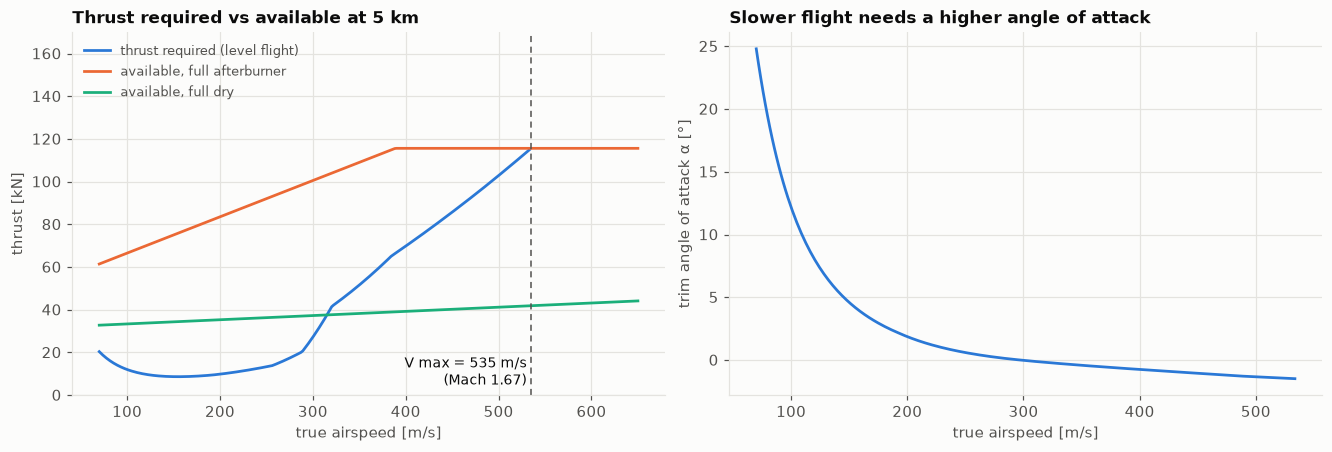

In [4]:
h = 5000.0
rho, a_sound = isa_scalar(h)[2], isa_scalar(h)[3]
speeds = np.linspace(70, 650, 300)
required, alphas = [], []
for v in speeds:
    try:
        alpha, power = ac.trim(h, v)
        required.append(ac.engine.thrust(power, rho, v / a_sound) / 1e3)
        alphas.append(alpha / DEG)
    except d3.TrimError:
        required.append(np.nan)
        alphas.append(np.nan)
required = np.array(required)

fig, axes = plt.subplots(1, 2, figsize=(12, 4), layout="constrained")
axes[0].plot(speeds, required, color=SERIES[0], label="thrust required (level flight)")
for power, label, color in (
    (1.0, "available, full afterburner", SERIES[1]),
    (params.propulsion.mil_power, "available, full dry", SERIES[2]),
):
    axes[0].plot(
        speeds,
        [ac.engine.thrust(power, rho, v / a_sound) / 1e3 for v in speeds],
        color=color,
        label=label,
    )
v_max = perf.level_speed_range(ac, h)[1]
axes[0].axvline(v_max, color=INK_2, linewidth=1, linestyle=(0, (4, 3)))
axes[0].text(
    v_max - 5,
    5,
    f"V max = {v_max:.0f} m/s\n(Mach {v_max / a_sound:.2f})",
    ha="right",
    color=INK,
    fontsize=9,
)
axes[0].set_xlabel("true airspeed [m/s]"), axes[0].set_ylabel("thrust [kN]")
axes[0].set_title(f"Thrust required vs available at {h / 1000:.0f} km")
axes[0].legend(loc="upper left", fontsize=8.5)
axes[0].set_ylim(0, 170)

axes[1].plot(speeds, alphas, color=SERIES[0])
axes[1].set_xlabel("true airspeed [m/s]"), axes[1].set_ylabel("trim angle of attack α [°]")
axes[1].set_title("Slower flight needs a higher angle of attack")
plt.show()

**Validation:** a trimmed state must stay trimmed. Simulating 60 s from the equilibrium, with
the trim controls held constant:

In [5]:
x0, u0 = ac.trimmed_state(5000, 220)
res = simulate(ac.derivatives, x0, 60.0, u_const=u0, post_step=ac.post_step)
print(
    f"after 60 s: altitude change {res.x[-1, d3.H] - x0[d3.H]:+.2e} m, "
    f"speed change {res.x[-1, d3.V] - x0[d3.V]:+.2e} m/s"
)

after 60 s: altitude change +0.00e+00 m, speed change +0.00e+00 m/s


## 5. The flight envelope

Repeating the thrust-required/available analysis at every altitude gives the envelope of
possible level flight. With specific excess power $P_s = V\,(T\cos\alpha - D)/(mg)$ (the
climb rate available at constant speed), level flight is possible wherever $P_s \ge 0$.

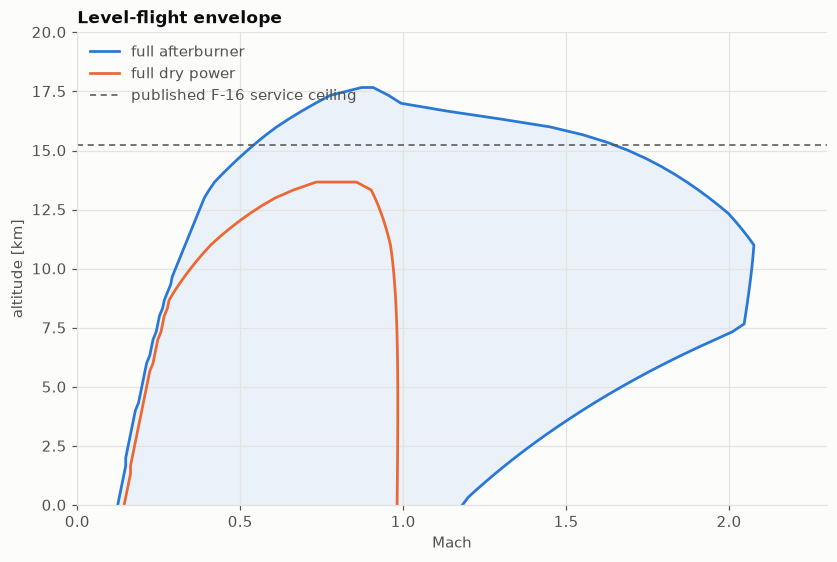

In [6]:
def envelope(power: float) -> np.ndarray:
    rows = []
    for alt in np.linspace(0, 19_000, 58):
        rng = perf.level_speed_range(ac, float(alt), power=power)
        if rng is not None:
            a = perf.speed_of_sound(float(alt))
            rows.append((alt, rng[0] / a, rng[1] / a))
    return np.array(rows)


fig, ax = plt.subplots(figsize=(7.5, 5), layout="constrained")
for power, label, color in (
    (1.0, "full afterburner", SERIES[0]),
    (params.propulsion.mil_power, "full dry power", SERIES[1]),
):
    env = envelope(power)
    mach_line = np.concatenate([env[:, 1], env[::-1, 2]])
    alt_line = np.concatenate([env[:, 0], env[::-1, 0]]) / 1000
    ax.plot(mach_line, alt_line, color=color, label=label)
    if power == 1.0:
        ax.fill(mach_line, alt_line, color=color, alpha=0.08, linewidth=0)
ax.axhline(
    params.limits.ceiling / 1000,
    color=INK_2,
    linewidth=1,
    linestyle=(0, (4, 3)),
    label="published F-16 service ceiling",
)
ax.set_xlabel("Mach"), ax.set_ylabel("altitude [km]")
ax.set_xlim(0, 2.3), ax.set_ylim(0, 20)
ax.set_title("Level-flight envelope")
ax.legend(loc="upper left")
plt.show()

The left boundary is the minimum speed (maximum α), the right boundary the maximum speed
(thrust = drag). Note how the afterburner roughly doubles the top speed at altitude: that
"bulge" past Mach 1 is the classic shape of a fighter envelope.

## 6. Turn performance

In a level turn at load factor $n = L/W$, the vertical component of lift balances the weight
and the horizontal one curves the trajectory:

$$\cos\mu = \frac1n, \qquad \omega = \frac{g\sqrt{n^2 - 1}}{V}, \qquad R = \frac{V}{\omega}$$

Two different limits matter for air combat:

* **instantaneous** turn rate — what you can pull right now (limited by $\alpha_{max}$ at low
  speed, by the 9 g structural limit at high speed), at the cost of bleeding speed;
* **sustained** turn rate — what you can hold forever, where thrust still equals drag.

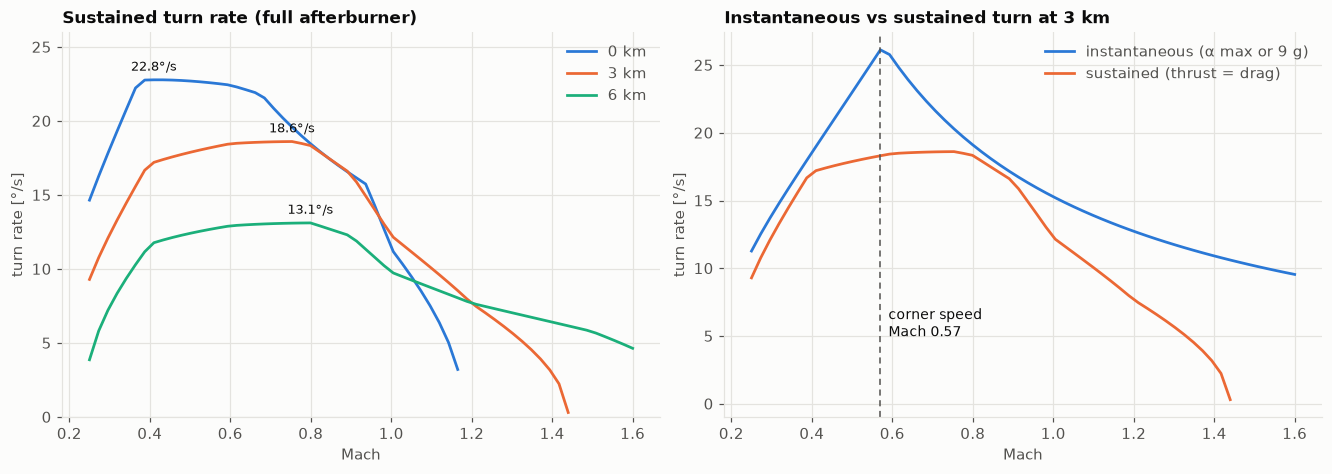

In [7]:
mach_grid = np.linspace(0.25, 1.6, 60)
fig, axes = plt.subplots(1, 2, figsize=(12, 4.2), layout="constrained")
for alt, color in zip((0.0, 3000.0, 6000.0), SERIES, strict=True):
    a = perf.speed_of_sound(alt)
    rates = []
    for m in mach_grid:
        turn = perf.sustained_turn(ac, alt, m * a)
        rates.append(math.degrees(turn.turn_rate) if turn else np.nan)
    rates = np.array(rates)
    axes[0].plot(mach_grid, rates, color=color, label=f"{alt / 1000:.0f} km")
    i = int(np.nanargmax(rates))
    axes[0].annotate(
        f"{rates[i]:.1f}°/s",
        (mach_grid[i], rates[i]),
        xytext=(0, 6),
        textcoords="offset points",
        ha="center",
        color=INK,
        fontsize=8.5,
    )
axes[0].set_xlabel("Mach"), axes[0].set_ylabel("turn rate [°/s]")
axes[0].set_title("Sustained turn rate (full afterburner)")
axes[0].set_ylim(0, 26)
axes[0].legend(loc="upper right")

alt = 3000.0
a = perf.speed_of_sound(alt)
inst = [math.degrees(perf.instantaneous_turn(ac, alt, m * a).turn_rate) for m in mach_grid]
sust = [
    math.degrees(t.turn_rate) if (t := perf.sustained_turn(ac, alt, m * a)) else np.nan
    for m in mach_grid
]
axes[1].plot(mach_grid, inst, color=SERIES[0], label="instantaneous (α max or 9 g)")
axes[1].plot(mach_grid, sust, color=SERIES[1], label="sustained (thrust = drag)")
corner = mach_grid[int(np.argmax(inst))]
axes[1].axvline(corner, color=INK_2, linewidth=1, linestyle=(0, (4, 3)))
axes[1].text(corner + 0.02, 5, f"corner speed\nMach {corner:.2f}", color=INK, fontsize=9)
axes[1].set_xlabel("Mach"), axes[1].set_ylabel("turn rate [°/s]")
axes[1].set_title("Instantaneous vs sustained turn at 3 km")
axes[1].legend(loc="upper right")
plt.show()

The **corner speed** is where the α limit and the 9 g limit meet: the fastest possible turn.
Above it the pilot is g-limited, below it lift-limited. The gap between the two curves is the
energy the aircraft loses per second if it keeps pulling — the trade-off at the heart of task
8.3 (notebook 8), where an early agent "cheated" by turning faster in a descending spiral.

## 7. Flying a loop

Full afterburner, α command at 25°, and let the physics do the rest. Thanks to the wind-frame
quaternion, the model goes through the vertical and over the top without any special case:

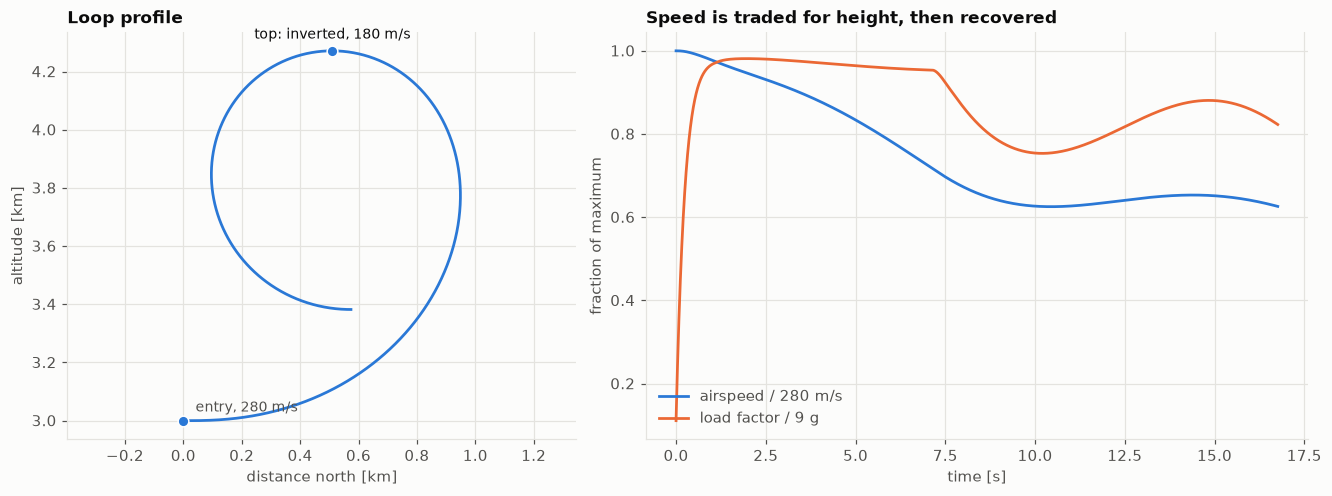

In [8]:
x0, _ = ac.trimmed_state(3000, 280)
res = simulate(
    ac.derivatives, x0, 22.0, u_const=np.array([1.0, 25 * DEG, 0.0]), post_step=ac.post_step
)
path_angle = np.unwrap(np.arctan2(np.gradient(res.x[:, d3.H]), np.gradient(res.x[:, d3.PN])))
end = int(np.searchsorted(path_angle - path_angle[0], 2 * math.pi)) + 1
data = [ac.flight_data(x) for x in res.x[:end]]
dist, alt = res.x[:end, d3.PN] / 1000, res.x[:end, d3.H] / 1000
speed = np.array([d.airspeed for d in data])
nz = np.array([d.load_factor for d in data])

fig, axes = plt.subplots(
    1, 2, figsize=(12, 4.4), layout="constrained", gridspec_kw={"width_ratios": [1, 1.3]}
)
axes[0].plot(dist, alt, color=SERIES[0])
top = int(np.argmax(alt))
axes[0].plot(
    dist[[0, top]], alt[[0, top]], "o", color=SERIES[0], markeredgecolor="white", markersize=7
)
axes[0].annotate(
    "entry, 280 m/s",
    (dist[0], alt[0]),
    xytext=(8, 6),
    textcoords="offset points",
    color=INK_2,
    fontsize=9,
)
axes[0].annotate(
    f"top: inverted, {speed[top]:.0f} m/s",
    (dist[top], alt[top]),
    xytext=(0, 8),
    textcoords="offset points",
    ha="center",
    color=INK,
    fontsize=9,
)
axes[0].set_aspect("equal", adjustable="datalim")
axes[0].set_xlabel("distance north [km]"), axes[0].set_ylabel("altitude [km]")
axes[0].set_title("Loop profile")

t = res.t[:end]
axes[1].plot(t, speed / speed.max(), color=SERIES[0], label=f"airspeed / {speed.max():.0f} m/s")
axes[1].plot(t, nz / 9.0, color=SERIES[1], label="load factor / 9 g")
axes[1].set_xlabel("time [s]"), axes[1].set_ylabel("fraction of maximum")
axes[1].set_title("Speed is traded for height, then recovered")
axes[1].legend(loc="lower left")
plt.show()

## 8. Validation against the real F-16

The whole point of this phase is a model that is *plausible*. Key figures, computed from the
model and compared with public data:

In [9]:
a0, a11 = perf.speed_of_sound(0.0), perf.speed_of_sound(11_000.0)
v3 = 0.8 * perf.speed_of_sound(3000.0)
rows = [
    ("max Mach at sea level", f"{perf.level_speed_range(ac, 0.0)[1] / a0:.2f}", "≈ 1.2"),
    ("max Mach at 11 km", f"{perf.level_speed_range(ac, 11_000.0)[1] / a11:.2f}", "≈ 2.0"),
    ("max climb rate at sea level [m/s]", f"{perf.max_rate_of_climb(ac, 0.0):.0f}", "≈ 250"),
    (
        "sustained turn, 3 km, M0.8 [°/s]",
        f"{math.degrees(perf.sustained_turn(ac, 3000, v3).turn_rate):.1f}",
        "≈ 18–20",
    ),
    ("ceiling (0.5 m/s climb) [km]", f"{perf.ceiling(ac) / 1000:.1f}", "15.2 (operational)"),
]
print(f"{'quantity':<38}{'model':>8}   public F-16 value")
for name, val, ref in rows:
    print(f"{name:<38}{val:>8}   {ref}")

x, u = ac.trimmed_state(3000, 263, load_factor=3)
t0 = time.perf_counter()
for _ in range(5000):
    x = ac.step(x, u)
rate = 5000 / (time.perf_counter() - t0)
print(f"\nsimulation speed: {rate:,.0f} physics steps/s = {rate * 0.01:,.0f}× real time")

quantity                                 model   public F-16 value
max Mach at sea level                     1.18   ≈ 1.2
max Mach at 11 km                         2.08   ≈ 2.0
max climb rate at sea level [m/s]          275   ≈ 250
sustained turn, 3 km, M0.8 [°/s]          18.3   ≈ 18–20
ceiling (0.5 m/s climb) [km]              17.7   15.2 (operational)

simulation speed: 37,706 physics steps/s = 377× real time


The model is within a few percent on speed, climb and turn. Known, documented limitations:
no stall model (so the minimum speed is optimistic), and an aerodynamic ceiling above the
published *operational* ceiling. Those are acceptable for a prototyping model.

## Takeaways

* The point-mass model integrates the **wind frame as a quaternion**: loops and vertical
  flight work without singularities.
* Aerodynamics (Mach-dependent polar) and propulsion (altitude + ram) are simple, sourced
  formulas, **calibrated against published F-16 performance**.
* Classic flight-mechanics tools — trim, thrust curves, envelope, turn diagrams — double as
  validation and as the source of **reference values** for the RL tasks (e.g. the optimal
  sustained turn in task 8.3).

**Next:** notebook 3 builds the full rigid-body model, where the agent must move real control
surfaces.